<a href="https://colab.research.google.com/github/Torranci/Project-CNN/blob/Torranci-AI-Security-Project/Project_Adversarial_Examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Adversarial Examples

In [1]:
import torch                          # Imports the main PyTorch library which provides the primary functions for building and training neural networks.
import torch.nn as nn                 # Imports the `torch.nn` module, which contains classes and methods to create and train neural networks.
import torch.optim as optim           # controls how the model learns
import torchvision                    # Importing Torchvision gives me easy access to the MNIST dataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
# this just helps speed things up if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
print("Device:", device)

# converting images into tensors so the model can read them
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,)) ])

Device: cpu


In [3]:
#Model Implentation
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# create the model and send it to device
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [4]:
#Making the Model Learn
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


In [5]:
# DataLoader helps break the dataset into batches
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

if train_loader is not None and test_loader is not None: # Corrected syntax
    print("The train_loader and test_loader now contain the MNIST dataset, ready for use in training and evaluation of a machine learning model.")

The train_loader and test_loader now contain the MNIST dataset, ready for use in training and evaluation of a machine learning model.


In [6]:
for name, param in model.named_parameters():
    print(name, param.grad)

conv1.weight None
conv1.bias None
conv2.weight None
conv2.bias None
fc1.weight None
fc1.bias None
fc2.weight None
fc2.bias None


In [7]:
epochs = 5

for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Acc: {correct/total:.4f}")

Epoch 1 | Loss: 0.1637 | Acc: 0.9492
Epoch 2 | Loss: 0.0552 | Acc: 0.9832
Epoch 3 | Loss: 0.0404 | Acc: 0.9875
Epoch 4 | Loss: 0.0300 | Acc: 0.9906
Epoch 5 | Loss: 0.0250 | Acc: 0.9924


In [8]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

clean_acc = correct / total
print("Clean Accuracy:", clean_acc)


Clean Accuracy: 0.9905


In [9]:
# FGSM Attacks
def fgsm_attack(image, epsilon, grad):
    sign_grad = grad.sign()
    adv = image + epsilon * sign_grad
    return torch.clamp(adv, -1, 1)

def test_fgsm(epsilon):
    model.eval()
    correct = 0
    examples = []

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        images.requires_grad = True

        outputs = model(images)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        adv_images = fgsm_attack(images, epsilon, images.grad)

        outputs = model(adv_images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        if len(examples) < 5:
            examples.append((images[0].cpu(), adv_images[0].cpu(), preds[0].item()))

    acc = correct / len(test_dataset)
    print(f"FGSM ε={epsilon} | Accuracy: {acc:.4f}")

    return acc, examples

In [10]:
# PGD Attacks
def pgd_attack(images, labels, epsilon, alpha, iters):
    ori = images.data

    for _ in range(iters):
        images.requires_grad = True

        outputs = model(images)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        images = images + alpha * images.grad.sign()

        eta = torch.clamp(images - ori, -epsilon, epsilon)
        images = torch.clamp(ori + eta, -1, 1).detach()

    return images

def test_pgd(epsilon):
    model.eval()
    correct = 0

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        adv = pgd_attack(images, labels, epsilon, 0.01, 10)

        outputs = model(adv)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

    acc = correct / len(test_dataset)
    print(f"PGD ε={epsilon} | Accuracy: {acc:.4f}")
    return acc

In [11]:
# Run Attacks
epsilons = [0, 0.05, 0.1, 0.2, 0.3]

fgsm_accs = []
pgd_accs = []
examples = []

for eps in epsilons:
    acc, ex = test_fgsm(eps)
    fgsm_accs.append(acc)
    examples.append(ex)

    pgd_accs.append(test_pgd(eps))

FGSM ε=0 | Accuracy: 0.9857
PGD ε=0 | Accuracy: 0.9857
FGSM ε=0.05 | Accuracy: 0.9726
PGD ε=0.05 | Accuracy: 0.9577
FGSM ε=0.1 | Accuracy: 0.9454
PGD ε=0.1 | Accuracy: 0.9034
FGSM ε=0.2 | Accuracy: 0.8469
PGD ε=0.2 | Accuracy: 0.9030
FGSM ε=0.3 | Accuracy: 0.6790
PGD ε=0.3 | Accuracy: 0.9005


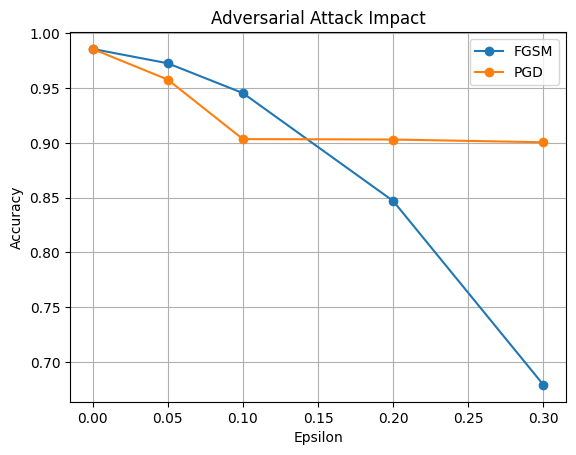

In [12]:
# Plot
plt.figure()
plt.plot(epsilons, fgsm_accs, marker='o', label="FGSM")
plt.plot(epsilons, pgd_accs, marker='o', label="PGD")
plt.title("Adversarial Attack Impact")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [13]:
def show_comparison(examples, epsilons):
    plt.figure(figsize=(10,6))
    count = 1

    for i in range(len(epsilons)):
        for j in range(len(examples[i])):

            orig, adv, pred = examples[i][j]

            # Original
            plt.subplot(len(epsilons), 10, count)
            plt.xticks([])
            plt.yticks([])
            plt.imshow(orig.squeeze(), cmap='gray')
            plt.title("Orig")
            count += 1

            # Adversarial
            plt.subplot(len(epsilons), 10, count)
            plt.xticks([])
            plt.yticks([])

            if j == 0:
                plt.ylabel(f"ε={epsilons[i]}")

            plt.imshow(adv.squeeze(), cmap='gray')
            plt.title(f"{pred}")
            count += 1

    plt.tight_layout()
    plt.show()

In [14]:
def show_examples(examples, epsilons):
    plt.figure(figsize=(12, 6))

    count = 1

    for i in range(len(epsilons)):
        for j in range(len(examples[i])):

            orig, adv, pred = examples[i][j]

            # ORIGINAL IMAGE
            plt.subplot(len(epsilons), 10, count)
            plt.xticks([])
            plt.yticks([])
            plt.imshow(orig.squeeze(), cmap='gray')
            plt.title("Orig")

            count += 1

            # ADVERSARIAL IMAGE
            plt.subplot(len(epsilons), 10, count)
            plt.xticks([])
            plt.yticks([])

            if j == 0:
                plt.ylabel(f"ε={epsilons[i]}")

            plt.imshow(adv.squeeze(), cmap='gray')
            plt.title(f"{pred}")

            count += 1

    plt.tight_layout()
    plt.show()

In [15]:
def get_feature_maps(model, image):
    model.eval()

    activation = {}

    def hook_fn(module, input, output):
        activation["conv1"] = output

    hook = model.conv1.register_forward_hook(hook_fn)

    with torch.no_grad():
        model(image)

    hook.remove()

    return activation["conv1"]

In [16]:
# Clean image
images, labels = next(iter(test_loader))
clean_img = images[0].unsqueeze(0).to(device)

# Adversarial image (from your saved FGSM examples)
orig, adv_img, pred = examples[0][0]

adv_img = adv_img.unsqueeze(0).to(device)

In [17]:
print("clean_img exists:", 'clean_img' in globals())
print("examples exists:", 'examples' in globals())

clean_img exists: True
examples exists: True


In [26]:
clean_maps = get_feature_maps(model, clean_img)
adv_maps = get_feature_maps(model, adv_img)

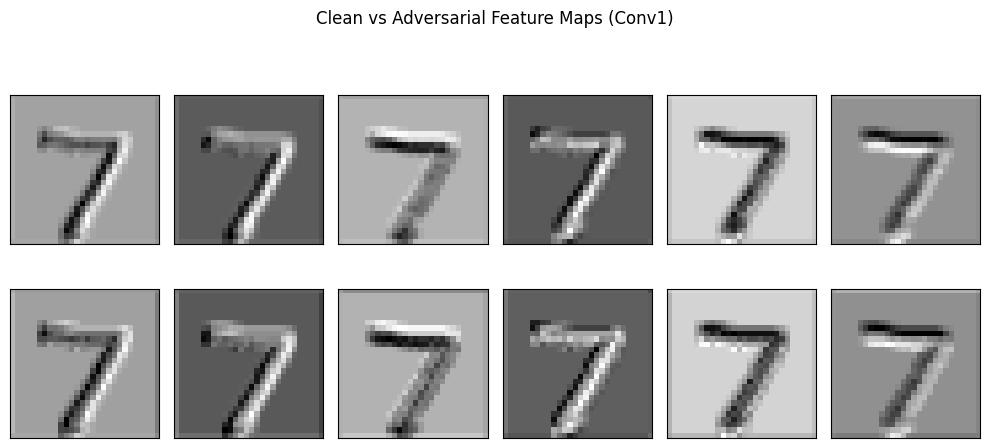

In [27]:
import matplotlib.pyplot as plt

num_maps = 6

plt.figure(figsize=(10,5))

for i in range(num_maps):

    # CLEAN
    plt.subplot(2, num_maps, i+1)
    plt.imshow(clean_maps[0, i].cpu(), cmap='gray')
    plt.xticks([])
    plt.yticks([])

    # ADVERSARIAL
    plt.subplot(2, num_maps, i+1+num_maps)
    plt.imshow(adv_maps[0, i].cpu(), cmap='gray')
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Clean vs Adversarial Feature Maps (Conv1)")
plt.tight_layout()
plt.show()